In [2]:
%pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.8 MB 12.1 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.8 MB 14.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 15.0 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 13.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries installed successfully!")

All libraries installed successfully!


In [31]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape of dataset:
(9800, 18)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   floa

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
df['Postal Code'].isnull().sum()

np.int64(11)

In [10]:
df['Postal Code'] = df['Postal Code'].fillna(0)

In [11]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', errors='coerce')

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [15]:
print("Missing Order Dates:", df['Order Date'].isnull().sum())
print("Missing Ship Dates:", df['Ship Date'].isnull().sum())

Missing Order Dates: 0
Missing Ship Dates: 0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object

In [19]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9800.000000,9800.000000
mean,4900.500000,2017-04-12 14:24:35.265306,2017-04-21 19:45:12.489796,55211.280918,230.769059
min,1.000000,2015-01-02 00:00:00,2015-01-04 00:00:00,0.000000,0.444000
25%,2450.750000,2016-05-02 12:00:00,2016-05-08 00:00:00,23223.000000,17.248000
50%,4900.500000,2017-05-30 00:00:00,2017-06-12 00:00:00,57551.000000,54.490000
75%,7350.250000,2018-04-11 00:00:00,2018-05-02 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-05-01 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32076.677954,626.651875


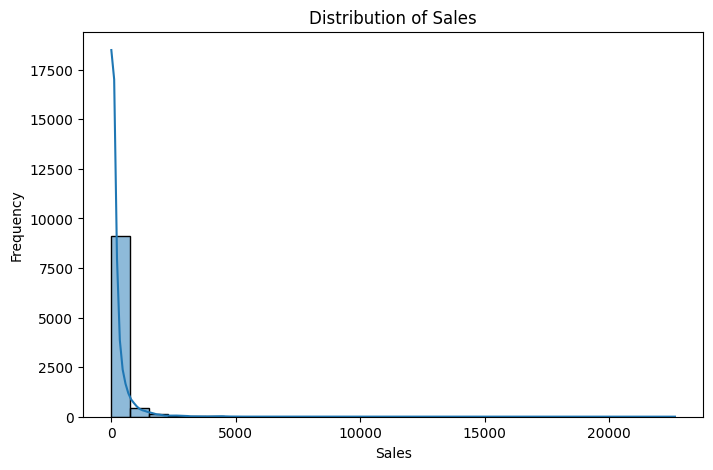

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

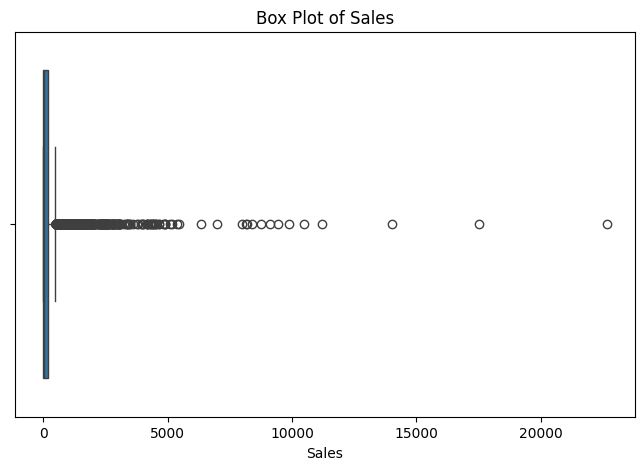

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Sales'])
plt.title('Box Plot of Sales')
plt.xlabel('Sales')
plt.show()

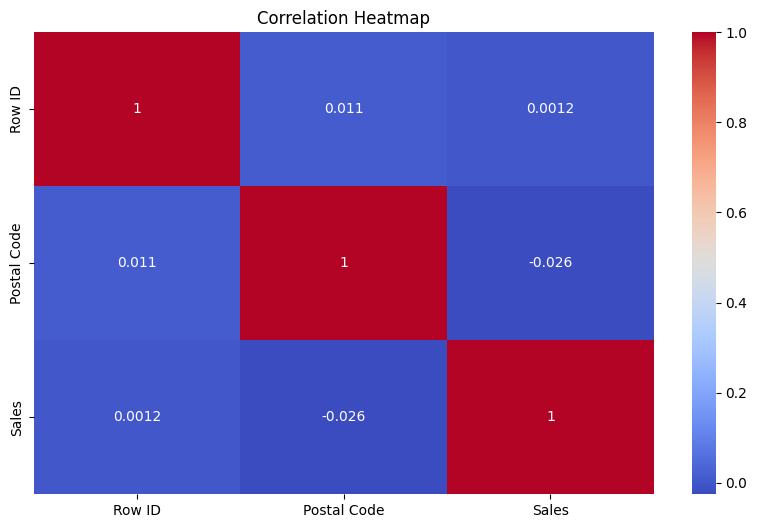

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

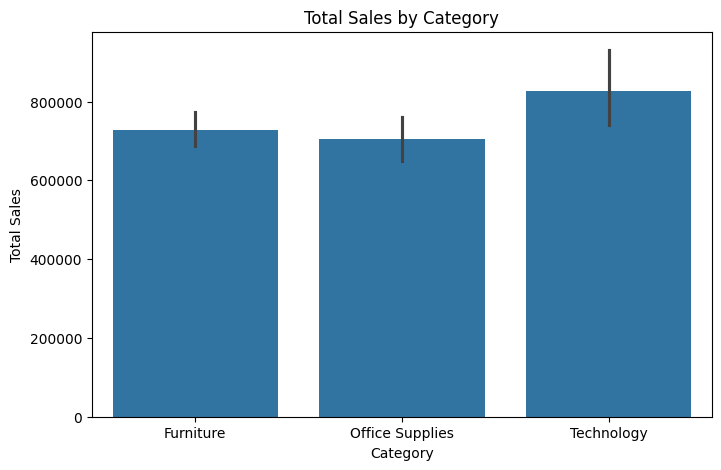

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Category', y='Sales', estimator='sum')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

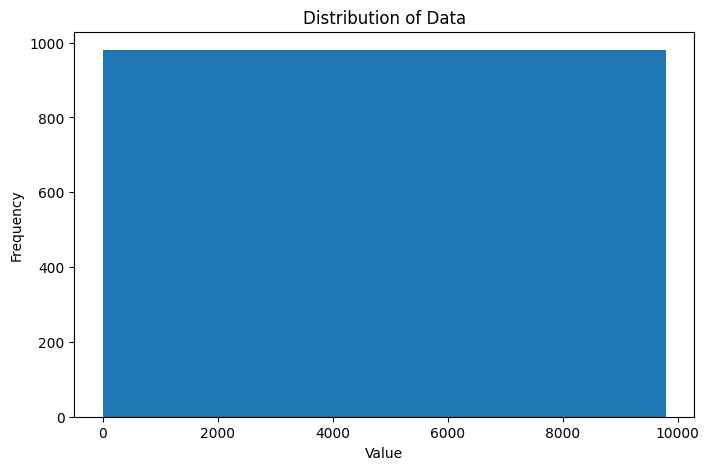

In [24]:
# Next visualization: Histogram

plt.figure(figsize=(8,5))
plt.hist(df.select_dtypes(include='number').iloc[:, 0], bins=10)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Distribution of Data")
plt.show()

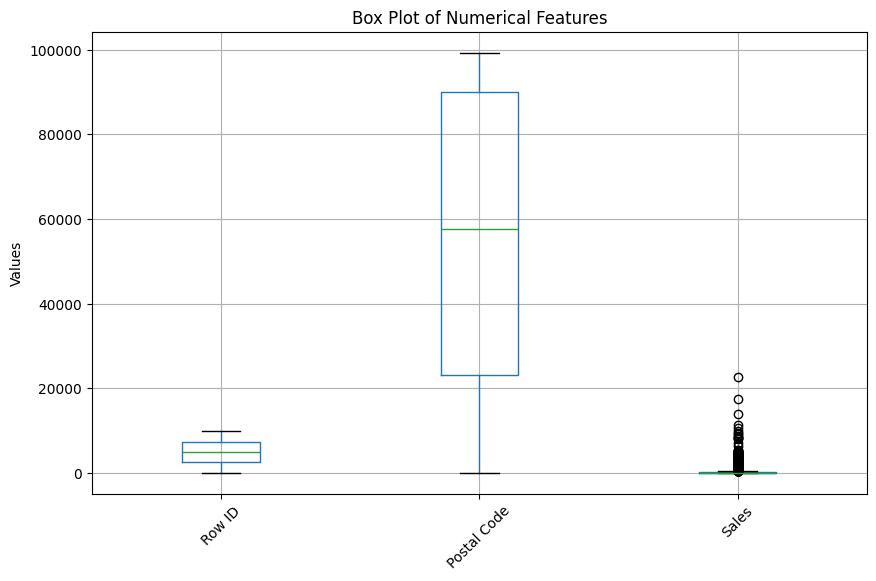

In [25]:
# Box Plot - Checking for Outliers

plt.figure(figsize=(10, 6))

numeric_data = df.select_dtypes(include='number')

numeric_data.boxplot()

plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

In [26]:
# Check for Missing Values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

Total missing values: 0


In [27]:
# Outlier Detection using IQR

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(f"{column}: {len(outliers)} outliers")

Row ID: 0 outliers
Postal Code: 0 outliers
Sales: 1145 outliers


In [28]:
# Check Categorical Columns

categorical_columns = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'Country', 'City', 'State', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name'],
      dtype='str')


C:\Users\Nagamma\AppData\Local\Temp\ipykernel_24180\2663515746.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [29]:
print(df.dtypes)


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object


In [30]:
# Count unique values in each column

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].nunique())


Row ID:
9800

Order ID:
4922

Order Date:
1230

Ship Date:
1326

Ship Mode:
4

Customer ID:
793

Customer Name:
793

Segment:
3

Country:
1

City:
529

State:
49

Postal Code:
627

Region:
4

Product ID:
1861

Category:
3

Sub-Category:
17

Product Name:
1849

Sales:
5757


In [32]:
# Display unique values of categorical columns

for column in df.columns:
    if df[column].dtype == 'object':
        print(f"\n{column}:")
        print(df[column].unique())

In [33]:
# Display unique values of categorical columns

for column in df.columns:
    if df[column].dtype == 'object':
        print(f"\n{column}:")
        print(df[column].unique())

In [37]:
# Find categorical columns

categorical_columns = df.select_dtypes(
    include=['object', 'category', 'string']
).columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'Country', 'City', 'State', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name'],
      dtype='str')


In [38]:
# Frequency of Categorical Values

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Order ID ---
Order ID
CA-2018-100111    14
CA-2018-157987    12
US-2017-108504    11
CA-2017-165330    11
CA-2016-131338    10
                  ..
CA-2017-104983     1
CA-2017-160234     1
CA-2016-155635     1
US-2015-114377     1
CA-2017-125920     1
Name: count, Length: 4922, dtype: int64

--- Ship Mode ---
Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

--- Customer ID ---
Customer ID
WB-21850    35
MA-17560    34
PP-18955    34
JL-15835    33
JD-15895    32
            ..
AO-10810     1
LD-16855     1
CJ-11875     1
SC-20845     1
RE-19405     1
Name: count, Length: 793, dtype: int64

--- Customer Name ---
Customer Name
William Brown        35
Matt Abelman         34
Paul Prost           34
John Lee             33
Jonathan Doherty     32
                     ..
Anthony O'Donnell     1
Lela Donovan          1
Carl Jackson          1
Sung Chung            1
Ricardo Emerson       1
Name: count, Leng

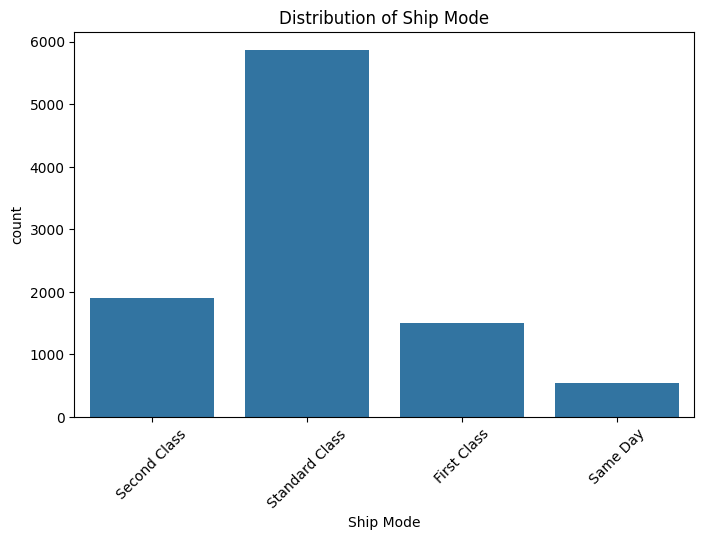

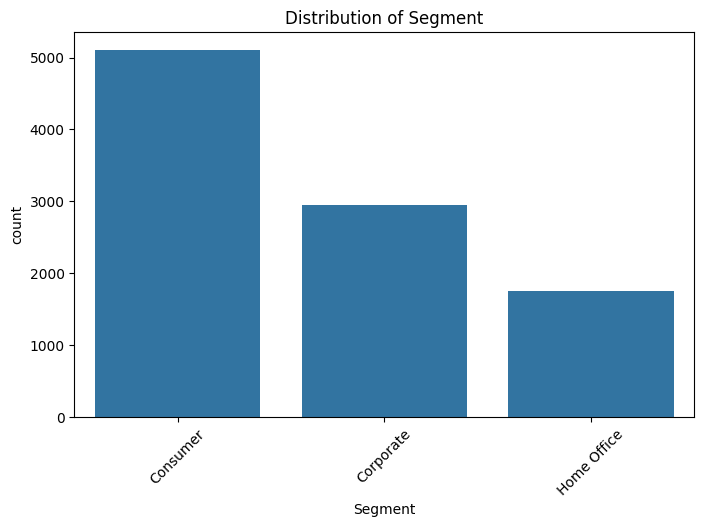

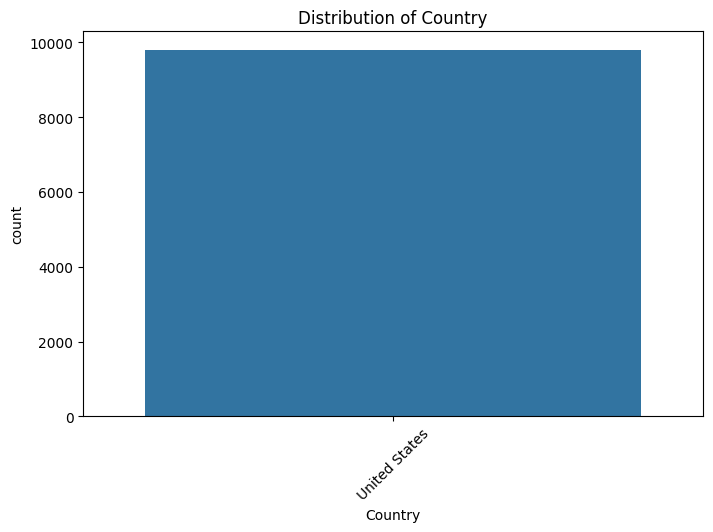

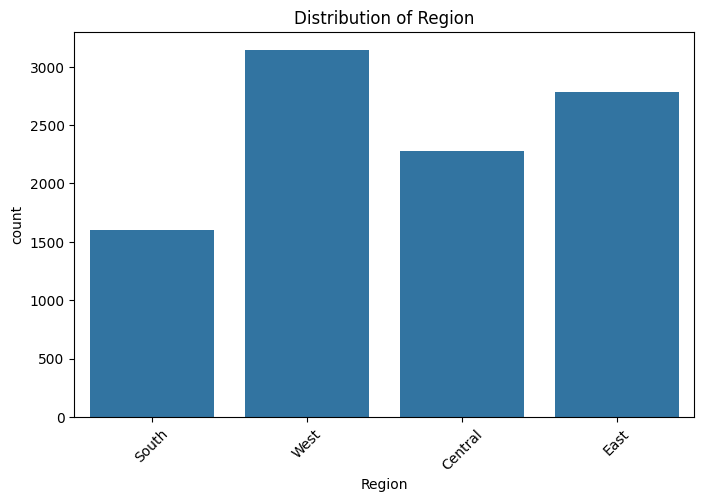

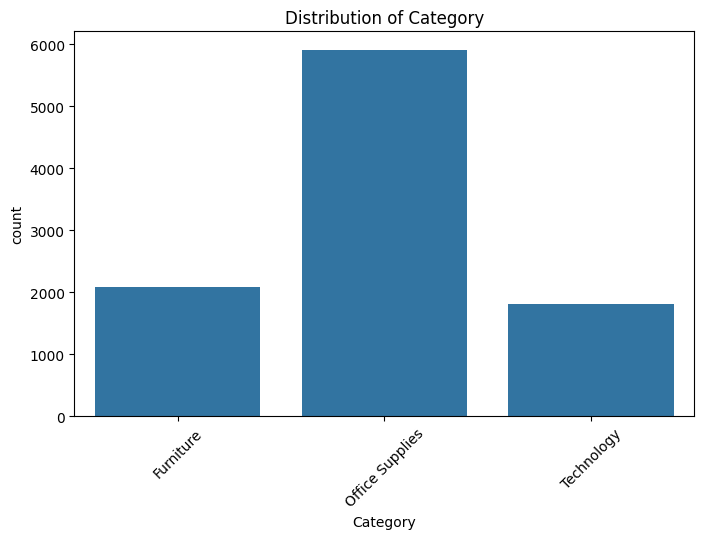

In [39]:
# Count Plot for Categorical Columns

import seaborn as sns
import matplotlib.pyplot as plt

for column in categorical_columns:
    if df[column].nunique() <= 10:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=column)
        plt.title(f"Distribution of {column}")
        plt.xticks(rotation=45)
        plt.show()

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


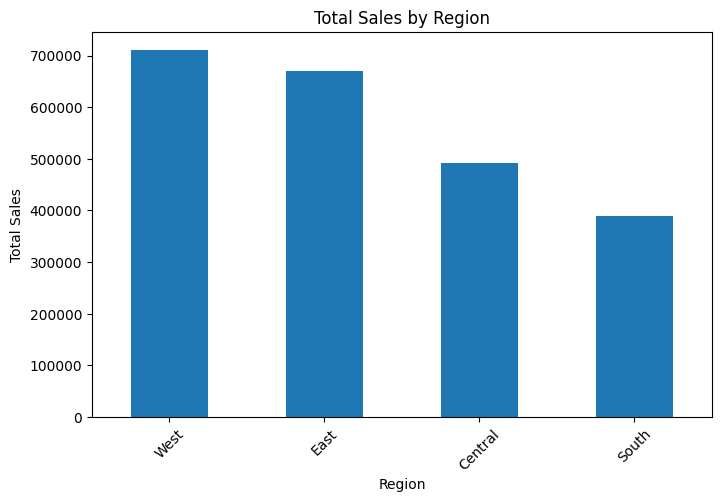

In [40]:
# Total Sales by Region

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar')

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [42]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [4]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

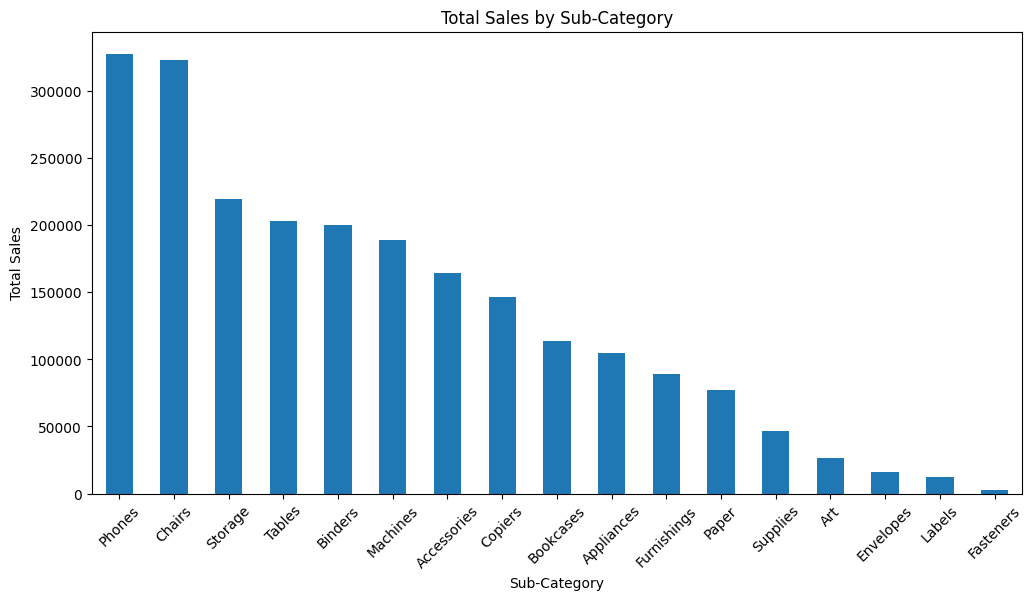

In [5]:
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

sales_by_subcategory.plot(kind='bar', figsize=(12,6))
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

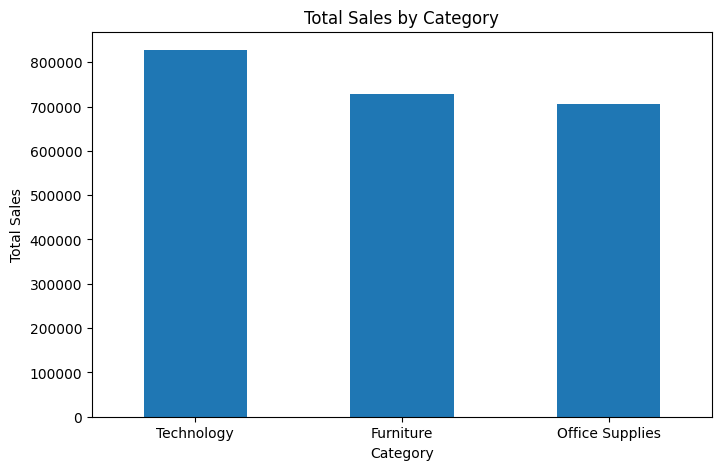

In [6]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

sales_by_category.plot(kind='bar', figsize=(8,5))
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

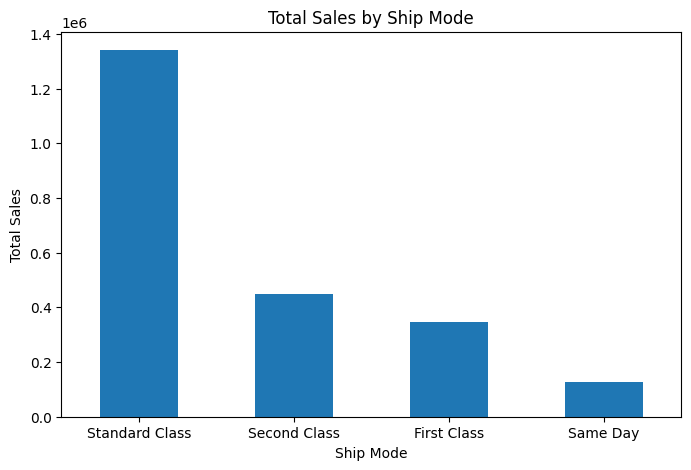

In [7]:
sales_by_ship_mode = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

sales_by_ship_mode.plot(kind='bar', figsize=(8,5))
plt.title('Total Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

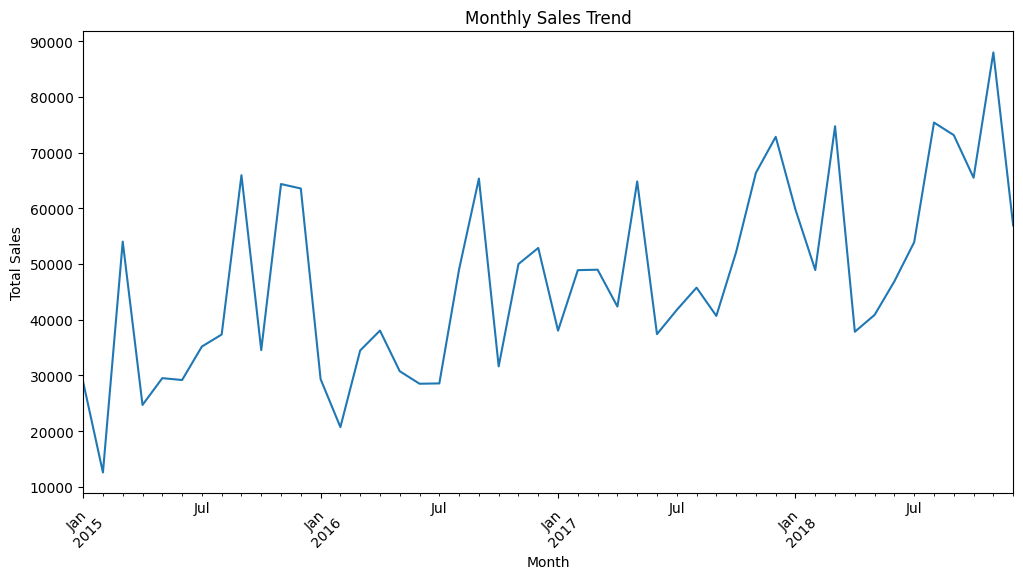

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', errors='coerce')

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.plot(kind='line', figsize=(12,6))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

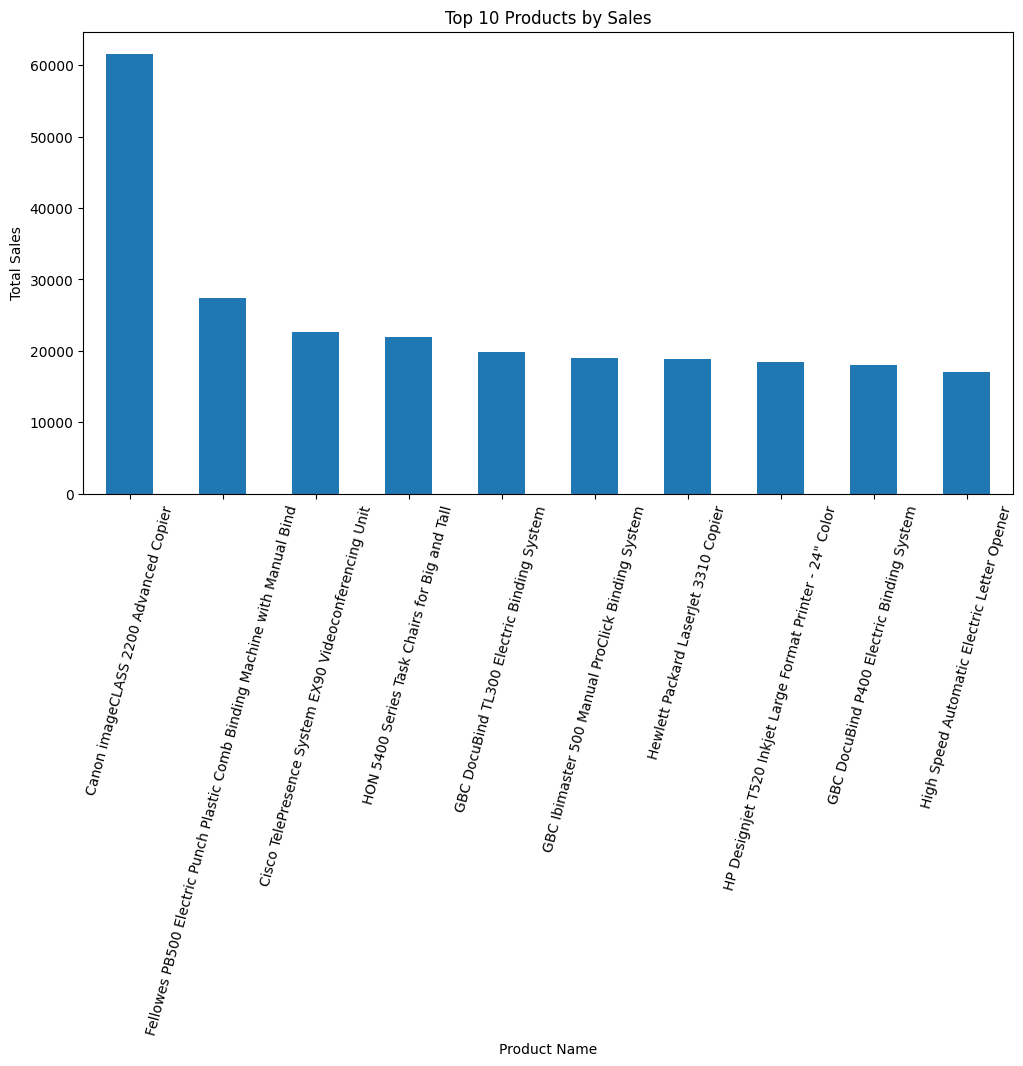

In [11]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Products by Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=75)
plt.show()

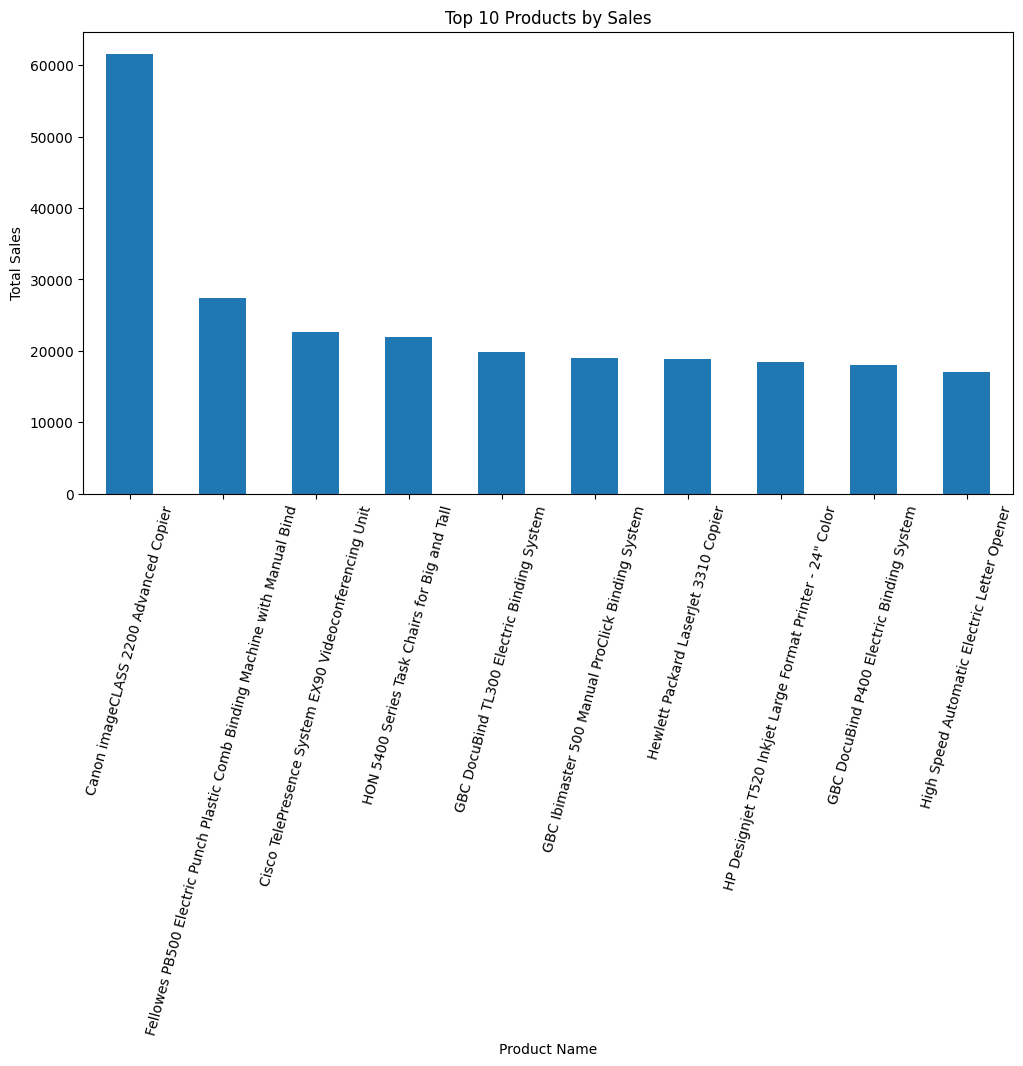

In [12]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Products by Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=75)
plt.show()

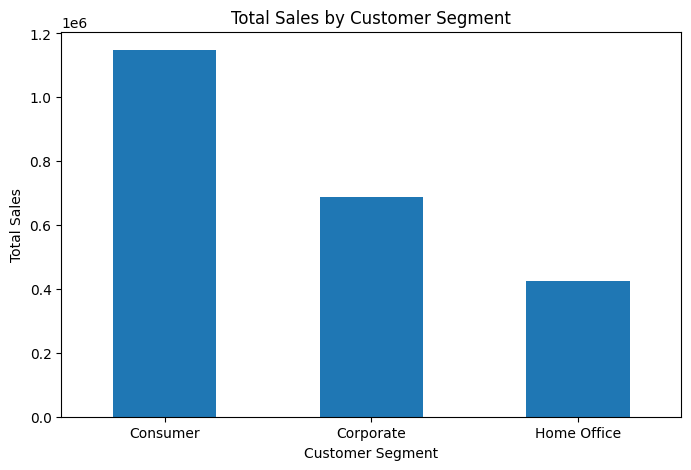

In [13]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

sales_by_segment.plot(kind='bar', figsize=(8,5))
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

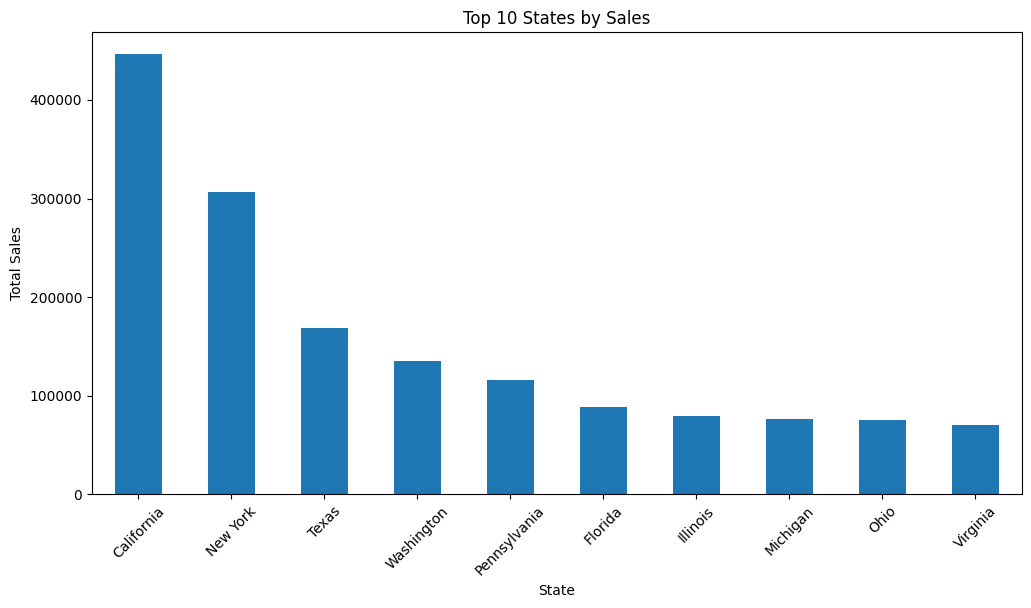

In [14]:
sales_by_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

sales_by_state.plot(kind='bar', figsize=(12,6))
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

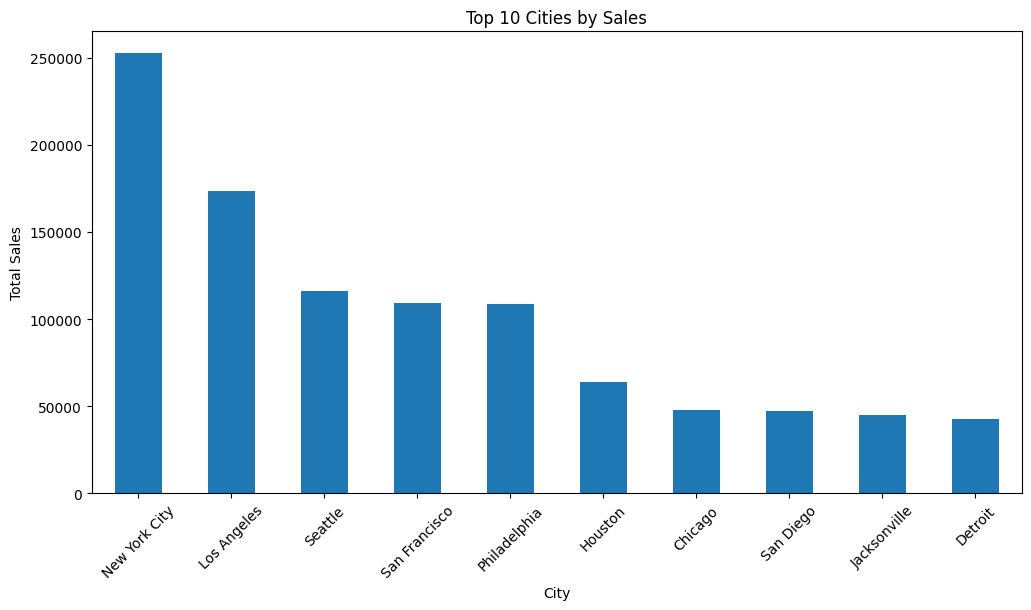

In [15]:
sales_by_city = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

sales_by_city.plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Cities by Sales')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [16]:
plt.figure(figsize=(10,6))
plt.hist(df['Discount'], bins=20)
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()

KeyError: 'Discount'

<Figure size 1000x600 with 0 Axes>

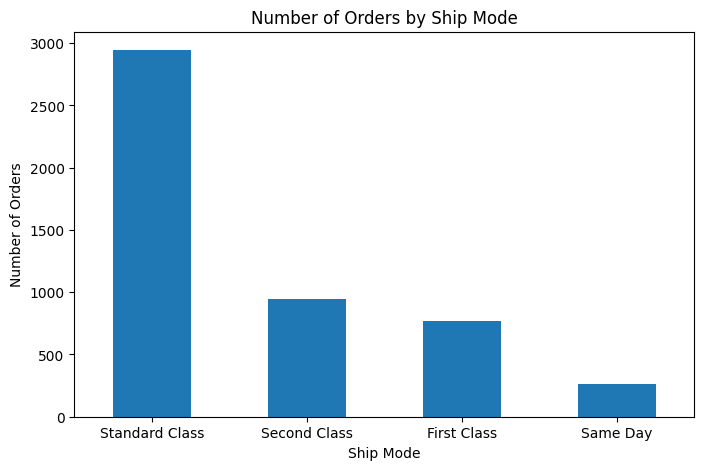

In [17]:
orders_by_ship_mode = df.groupby('Ship Mode')['Order ID'].nunique().sort_values(ascending=False)

orders_by_ship_mode.plot(kind='bar', figsize=(8,5))
plt.title('Number of Orders by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

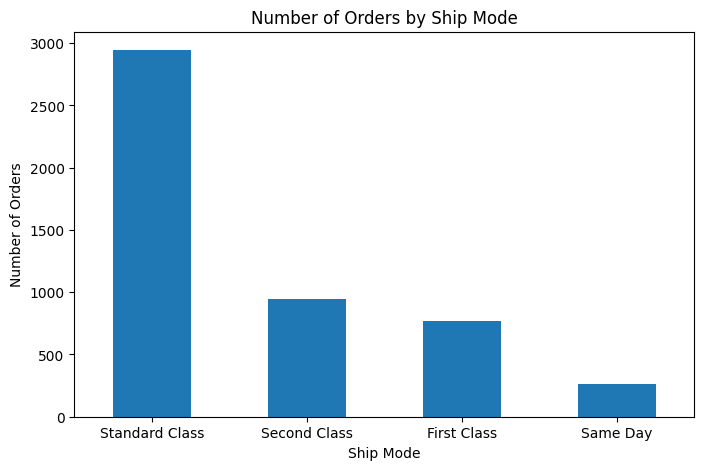

In [18]:
orders_by_ship_mode = df.groupby('Ship Mode')['Order ID'].nunique().sort_values(ascending=False)

orders_by_ship_mode.plot(kind='bar', figsize=(8,5))
plt.title('Number of Orders by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

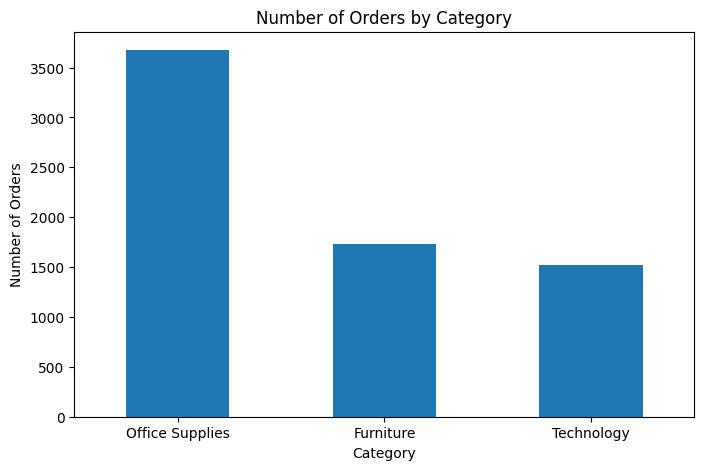

In [19]:
orders_by_category = df.groupby('Category')['Order ID'].nunique().sort_values(ascending=False)

orders_by_category.plot(kind='bar', figsize=(8,5))
plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

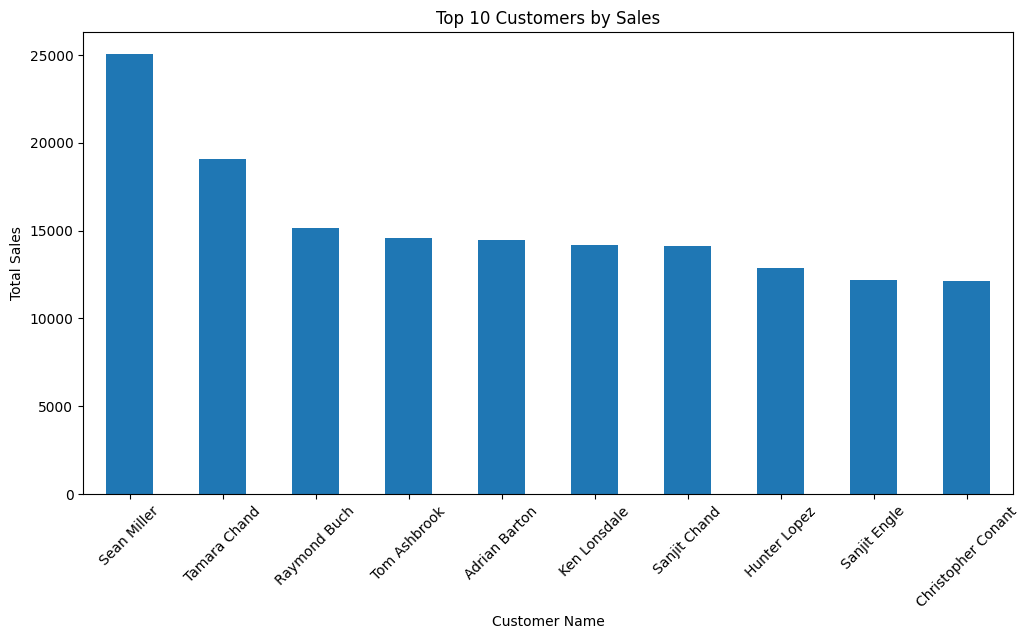

In [20]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

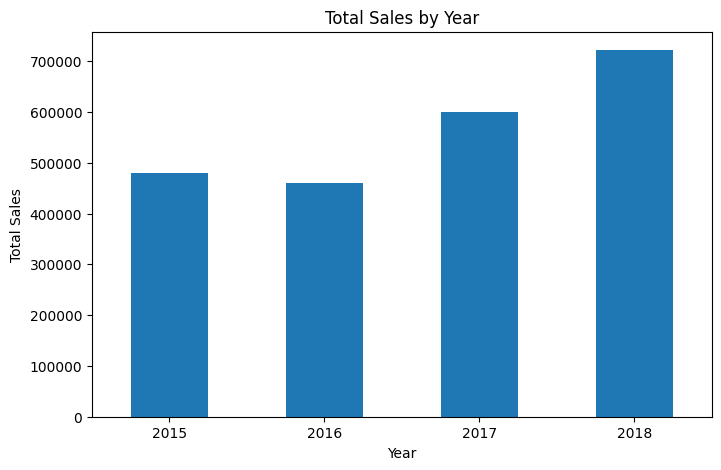

In [23]:
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

yearly_sales.plot(kind='bar', figsize=(8,5))
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

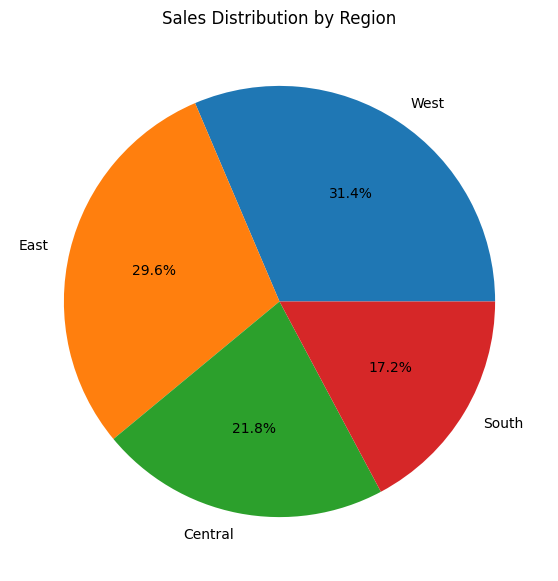

In [24]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

sales_by_region.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Sales Distribution by Region')
plt.ylabel('')
plt.show()

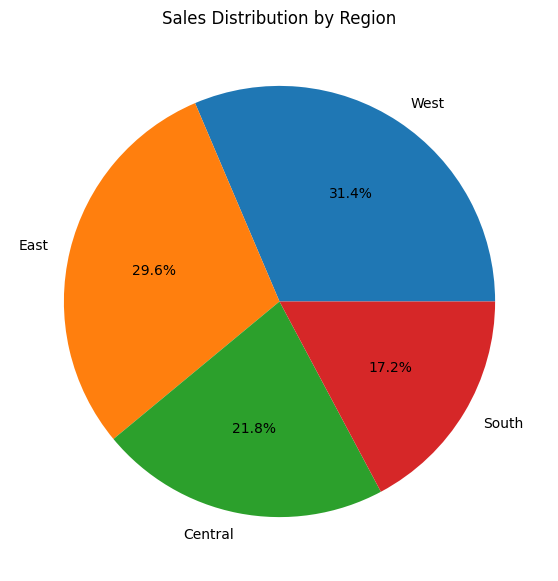

In [25]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

sales_by_region.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title('Sales Distribution by Region')
plt.ylabel('')
plt.show()

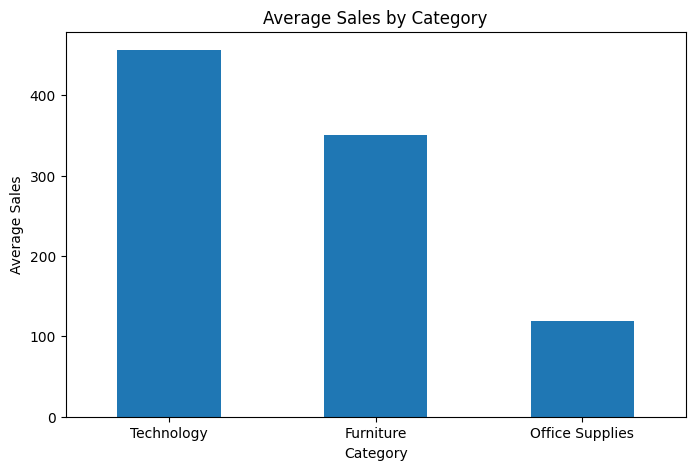

In [26]:
avg_sales_category = df.groupby('Category')['Sales'].mean().sort_values(ascending=False)

avg_sales_category.plot(kind='bar', figsize=(8,5))
plt.title('Average Sales by Category')
plt.xlabel('Category')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

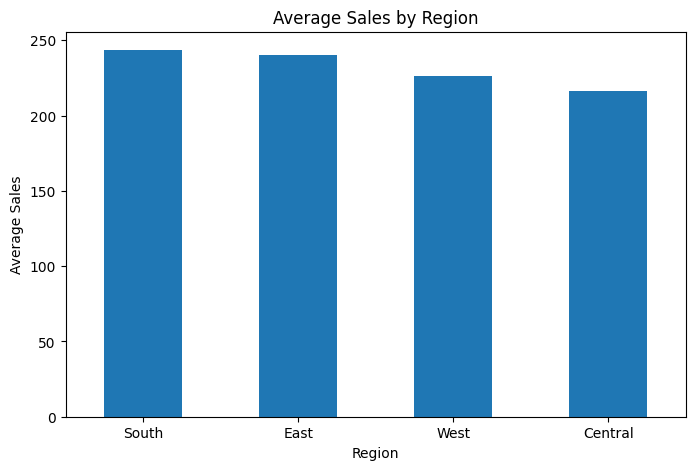

In [27]:
avg_sales_region = df.groupby('Region')['Sales'].mean().sort_values(ascending=False)

avg_sales_region.plot(kind='bar', figsize=(8,5))
plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

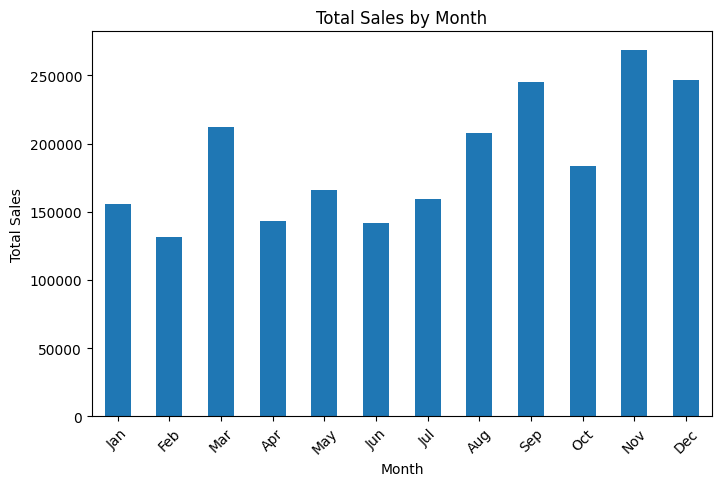

In [28]:
monthly_sales_by_month = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

monthly_sales_by_month.plot(kind='bar', figsize=(8,5))
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.show()

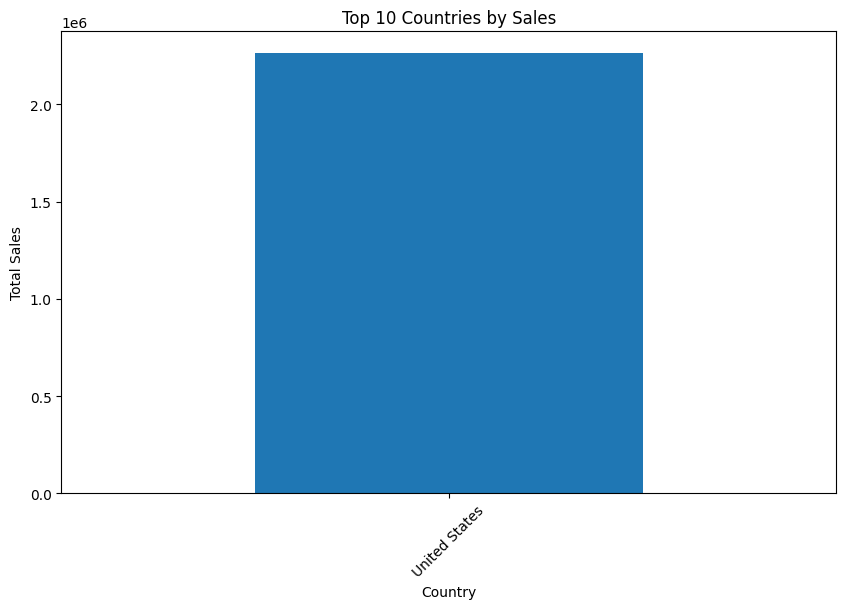

In [33]:
sales_by_country = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

sales_by_country.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [34]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [35]:
print("KEY SALES FINDINGS")
print("-------------------")

print("Highest Sales Category:", df.groupby('Category')['Sales'].sum().idxmax())
print("Highest Sales Region:", df.groupby('Region')['Sales'].sum().idxmax())
print("Highest Sales Segment:", df.groupby('Segment')['Sales'].sum().idxmax())
print("Highest Sales Ship Mode:", df.groupby('Ship Mode')['Sales'].sum().idxmax())
print("Top Selling Product:", df.groupby('Product Name')['Sales'].sum().idxmax())
print("Top Selling State:", df.groupby('State')['Sales'].sum().idxmax())
print("Top Selling City:", df.groupby('City')['Sales'].sum().idxmax())

KEY SALES FINDINGS
-------------------
Highest Sales Category: Technology
Highest Sales Region: West
Highest Sales Segment: Consumer
Highest Sales Ship Mode: Standard Class
Top Selling Product: Canon imageCLASS 2200 Advanced Copier
Top Selling State: California
Top Selling City: New York City


# Conclusion

This project analyzed sales data using Python, Pandas, Matplotlib, and data visualization techniques. The analysis included sales trends by month and year, category, sub-category, region, state, city, customer segment, ship mode, and top-performing products and customers.

The visualizations helped identify important sales patterns and high-performing areas. Overall, the analysis provides useful insights into customer behavior, product performance, regional sales, and sales trends that can support better business decision-making.az